In [1]:
!pip install pingouin
!pip install geopy
import pandas as pd
import matplotlib.colors as mcolors
import colorsys
import itertools
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from heatindex import heatindex
from tqdm import tqdm
import pingouin as pg
# !pip install geopy
import itertools
tqdm.pandas()
from mpl_toolkits.axes_grid1 import make_axes_locatable
from geopy.distance import geodesic

In [2]:
outdoor_temp = pd.read_csv('./campaign_data/outdoor_temp.csv')

figure_directory = 'paper_plots'

# Convert 'Date/Time' to datetime format
outdoor_temp['Date/Time'] = pd.to_datetime(outdoor_temp['Date/Time'])

# Set 'Date/Time' as the index
outdoor_temp.set_index('Date/Time', inplace=True)

outdoor_temp['Hour'] = outdoor_temp.index.hour

# Humidity data
outdoor_hum = pd.read_csv('./campaign_data/outdoor_hum.csv')

# Convert 'Date/Time' to datetime format
outdoor_hum['Date/Time'] = pd.to_datetime(outdoor_hum['Date/Time'])

# Set 'Date/Time' as the index
outdoor_hum.set_index('Date/Time', inplace=True)

outdoor_hum['Hour'] = outdoor_hum.index.hour

# Now you can safely round the index and extract the hour
outdoor_temp['Original_Outdoor_Time'] = outdoor_temp.index.round('H').hour

# Filter out rows where Lat or Lon is NaN
filtered_pairs = outdoor_temp.dropna(subset=['gps_lat_out', 'gps_long_out'])

# Extract unique latitude-longitude pairs and set them as index
unique_pairs = filtered_pairs[['gps_lat_out', 'gps_long_out']].drop_duplicates()
unique_pairs.set_index(['gps_lat_out', 'gps_long_out'], inplace=True)

# Reference point
## CENSUS BASED
ref_label = "census"
ref_point = (5.62437, -0.21988)

## MAKOLA MARKET
# ref_label = "makola"
# ref_point = (5.547805458658239, -0.20714336436033923)

## INDEPENDENCE_ARCH
# ref_label = "independence_arch"
# ref_point = (5.548988910639818, -0.19285475638140318)

## OXFORD_STREET
# ref_label = "oxford_st"
# ref_point = (5.559818808959416, -0.1821397658288711)

# Compute the distance for each unique pair
unique_pairs['distance'] = unique_pairs.index.map(lambda x: geodesic(x, ref_point).km)

# Map these computed distances back to the main dataframe
outdoor_temp['distance'] = outdoor_temp.set_index(['gps_lat_out', 'gps_long_out']).index.map(unique_pairs['distance'].to_dict())

# For rows with NaN lat/lon, set distance to NaN
outdoor_temp.loc[outdoor_temp['gps_lat_out'].isna() | outdoor_temp['gps_long_out'].isna(), 'distance'] = None

/tmp/ipykernel_10013/3683027292.py:1: DtypeWarning: Columns (7,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_temp = pd.read_csv('./campaign_data/outdoor_temp.csv')
/tmp/ipykernel_10013/3683027292.py:14: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_hum = pd.read_csv('./campaign_data/outdoor_hum.csv')


In [3]:
site_type = {'AD': ['Asylum Down', 'Commercial/\nbusiness/\nindustrial','blue'],
             'ASH' : ['Ashaiman', 'Medium/low-density\nresidential', 'tab:orange'],
             'EL': ['East Legon', 'Medium/low-density\nresidential', 'tab:orange'],
             'JT' : ['James Town', 'High-density\nresidential', 'red'],
             'LA': ['Labadi', 'Medium/low-density\nresidential', 'tab:orange'],
             'N1W': ['N1 West Motorway', 'Commercial/\nbusiness/\nindustrial','blue'],
             'NM': ['Nima', 'High-density\nresidential', 'red'],
             'TF': ['Taifa','Medium/low-density\nresidential', 'tab:orange'],
             'TMW': ['Tema Motorway', 'Commercial/\nbusiness/\nindustrial','blue'],
             'UGH': ['University of Ghana', 'Peri-urban background', 'green']}

land_use_type = {'low-dens' : 'Medium/low-density residential', 'high-dens': 'High-density residential', 'commercial': 'Commercial/business/industrial', 'other': 'Peri-urban background' }

In [4]:
# Group by 'sensor_id' and calculate the number of unique 'site_id's for each 'sensor_id'
unique_site_ids_per_sensor = outdoor_temp.groupby('sensor_id_outdoor_temp')['site_id'].nunique()

# Check if any 'sensor_id' is associated with more than one 'site_id'
multiple_sites_per_sensor = unique_site_ids_per_sensor[unique_site_ids_per_sensor > 1]

if len(multiple_sites_per_sensor) > 0:
    print("These sensor_ids are associated with multiple site_ids:")
    print(multiple_sites_per_sensor)
else:
    print("Every sensor_id is associated with a unique site_id.")


Every sensor_id is associated with a unique site_id.


<Axes: >

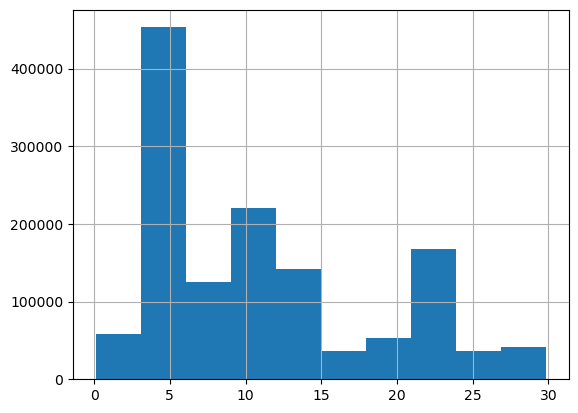

In [5]:
# outdoor_temp.columns
outdoor_temp['distance'].hist()

In [6]:
ndvi_values = pd.read_csv('updated_sites_lat_long_ndvi.csv')
ndbi_values = pd.read_csv('updated_sites_lat_long_ndbi.csv')
# site_densities = pd.read_csv('../site_cats_densities.csv')

In [7]:
# indoor_temp = pd.read_csv('./tagged_data_no_threshold/indoor_sen_meta_tagged.csv') 
indoor_temp = pd.read_csv('./campaign_data/indoor_temp.csv')
indoor_temp['Date/Time'] = pd.to_datetime(indoor_temp['Date/Time'])
indoor_temp.set_index('Date/Time', inplace=True)
common_sites = set(indoor_temp['site_id']).intersection(set(outdoor_temp['site_id']))

/tmp/ipykernel_10013/3531141079.py:2: DtypeWarning: Columns (7,8,11,12,13,25,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  indoor_temp = pd.read_csv('./campaign_data/indoor_temp.csv')


In [8]:
# Rename 'Value' column in indoor dataframe to avoid confusion after merge
indoor_temp.rename(columns={'Value': 'Indoor_Value'}, inplace=True)

indoor_temp['Original_Indoor_Time'] = indoor_temp.index.round('H').hour
# outdoor_temp['Original_Outdoor_Time'] = outdoor_temp.index.round('H').hour

# Sort both dataframes by 'Date/Time' and 'site_id'
outdoor_temp.sort_values(['Date/Time', 'site_id'], inplace=True)
indoor_temp.sort_values(['Date/Time', 'site_id'], 
                        inplace=True)

# Merge the dataframes
merged_df = pd.merge_asof(indoor_temp, outdoor_temp, 
                          on='Date/Time', by='site_id', 
                          tolerance=pd.Timedelta('1 hour'), direction='nearest', suffixes = ('_outdoor', '_indoor'))

merged_df['Temp_diff'] = merged_df['Indoor_Value'] - merged_df['Value']
merged_df['Date/Time'] = pd.to_datetime(merged_df['Date/Time'])
merged_df['Day/night'] = merged_df['Date/Time'].dt.hour.apply(lambda x: 'Day' if 6 <= x < 18 else 'Night')


In [9]:
# Assuming merged_df and ndvi_values are already loaded as described
# Convert 'site_id' to string if not already (in both dataframes)
merged_df['site_id'] = merged_df['site_id'].astype(str)
ndvi_values['site_id'] = ndvi_values['site_id'].astype(str)
ndbi_values['site_id'] = ndbi_values['site_id'].astype(str)

# Merge NDVI values with merged_df
merged_df = pd.merge(merged_df, ndvi_values[['site_id', 'mean_ndvi']], on='site_id', how='left')
# Merge NDVI values with merged_df
merged_df = pd.merge(merged_df, ndbi_values[['site_id', 'mean_ndbi']], on='site_id', how='left')

# Now merged_df contains the NDVI values along with other data


In [10]:
# Assuming your dataframe has a datetime column named "timestamp"
merged_df['Date'] = merged_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level = merged_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor=('Indoor_Value', 'mean'),
    daily_mean_outdoor=('Value', 'mean'),
    daily_max_indoor=('Indoor_Value', 'max'),
    daily_max_outdoor=('Value', 'max'),
    site_type_outdoor=('site_type_outdoor', 'first'),
    mean_ndvi=('mean_ndvi', 'first'),
    mean_ndbi=('mean_ndbi', 'first'),
    distance=('distance', 'first')
).reset_index()

# Step 2: Calculate daily differences and aggregate
# We need to include the additional columns ('distance', 'mean_ndvi', 'mean_ndbi')
day_diff = day_level.pivot(index=['sensor_id_indoor_temp', 'Date'], columns='Day/night', values=['daily_mean_outdoor', 'daily_mean_indoor', 'distance', 'mean_ndvi', 'mean_ndbi'])
day_diff.columns = ['_'.join(col).strip() for col in day_diff.columns.values]
day_diff['daily_diff_outdoor'] = day_diff['daily_mean_outdoor_Night'] - day_diff['daily_mean_outdoor_Day']
day_diff['daily_diff_indoor'] = day_diff['daily_mean_indoor_Night'] - day_diff['daily_mean_indoor_Day']
day_diff = day_diff.reset_index()

# Step 3: Sensor-Level Aggregation
aggregated_data = day_level.groupby(['sensor_id_indoor_temp', 'Day/night']).agg(
    average_daily_mean_indoor=('daily_mean_indoor', 'mean'),
    average_daily_mean_outdoor=('daily_mean_outdoor', 'mean'),
    average_daily_max_indoor=('daily_max_indoor', 'mean'),
    average_daily_max_outdoor=('daily_max_outdoor', 'mean'),
    mean_ndvi=('mean_ndvi', 'first'),
    mean_ndbi=('mean_ndbi', 'first'),
    distance=('distance', 'first')
).reset_index()

# Aggregated day-night differences
aggregated_diff = day_diff.groupby('sensor_id_indoor_temp').agg(
    average_diff_outdoor=('daily_diff_outdoor', 'mean'),
    average_diff_indoor=('daily_diff_indoor', 'mean'),
    mean_ndvi=('mean_ndvi_Day', 'first'),
    mean_ndbi=('mean_ndbi_Day', 'first'),
    distance=('distance_Day', 'first')
).reset_index()


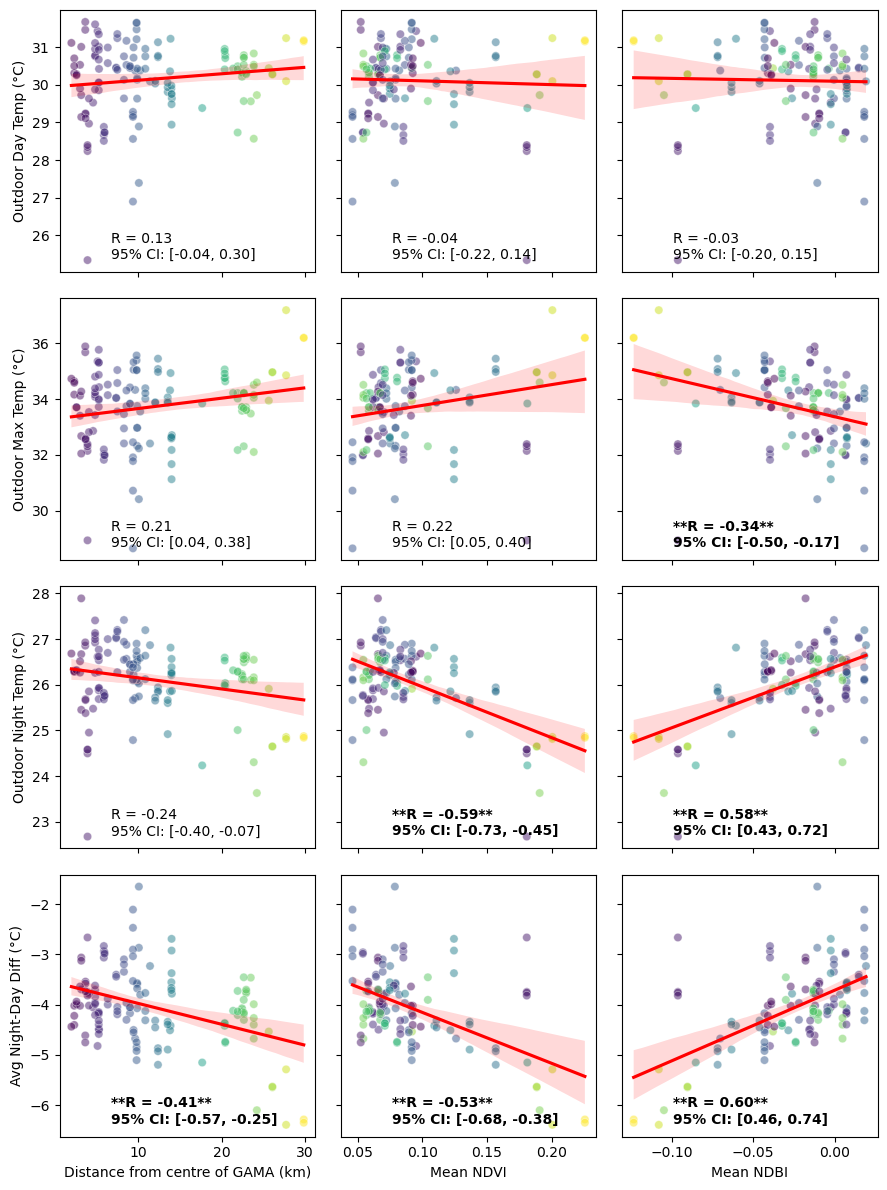

In [11]:
import statsmodels.api as sm

def annotate_fit_r(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(df) < 2:
        return
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    r = np.sqrt(model.rsquared) if model.params['x'] > 0 else -np.sqrt(model.rsquared)
    
    # Calculate the confidence interval for R using Pearson correlation
    r_value, p_value = stats.pearsonr(df['x'], df['y'])
    ci_low, ci_high = stats.norm.interval(0.95, loc=r_value, scale=np.sqrt((1-r_value**2)/(len(df)-2)))
    
    # Bonferroni corrected significance level
    corrected_p = 0.05 / 26
    significant = p_value < corrected_p

    # Annotate with bold and asterisk if significant
    if significant:
        ax.annotate(f'**R = {r_value:.2f}**\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]', 
                    xy=(0.2, 0.05), xycoords='axes fraction', fontsize=10, fontweight='bold')
    else:
        ax.annotate(f'R = {r_value:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]', 
                    xy=(0.2, 0.05), xycoords='axes fraction', fontsize=10)

# Choose the analysis level
analysis_level = 'aggregated'  # Set to either 'day_level' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame = day_level
    axis_prefix = 'daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data

# Create the 4x3 plot grid
fig, axes = plt.subplots(4, 3, figsize=(9, 12), sharex='col', sharey='row')

# Define the variables to plot
x_vars = ['distance', 'mean_ndvi', 'mean_ndbi']
y_vars = [
    'average_daily_mean_outdoor',
    'average_daily_max_outdoor',
    'average_daily_mean_outdoor',
    'average_diff_outdoor'
]

day_night_flags = ['Day', 'Day', 'Night', 'None']

titles = ['Distance from centre of GAMA (km)', 'Mean NDVI', 'Mean NDBI']
y_labels = [
    'Outdoor Day Temp (°C)',
    'Outdoor Max Temp (°C)',
    'Outdoor Night Temp (°C)',
    'Avg Night-Day Diff (°C)'
]

# Plot each combination
for i, (y_var, day_night_flag) in enumerate(zip(y_vars, day_night_flags)):
    for j, (x_var, title) in enumerate(zip(x_vars, titles)):
        ax = axes[i, j]
        if day_night_flag != 'None':
            data = analysis_frame[analysis_frame['Day/night'] == day_night_flag]
        else:
            data = aggregated_diff
        sns.scatterplot(
            data=data, 
            x=x_var, 
            y=y_var,
            hue='distance',
            palette='viridis',
            alpha=0.5,
            legend=False,
            ax=ax
        )
        sns.regplot(
            data=data, 
            x=x_var, 
            y=y_var,
            scatter=False,
            line_kws={'color': 'red'},
            ci=95,
            ax=ax
        )
        if j == 0:
            ax.set_ylabel(y_labels[i])
        else:
            ax.set_ylabel('')
        if i == 3:
            ax.set_xlabel(title)
        else:
            ax.set_xlabel('')
        annotate_fit_r(data[x_var], data[y_var], ax)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.1)

# Save and show the plot
plt.savefig(f"paper_plots/distance_ndvi/sensitivity_plots/{ref_label}/{analysis_level}_outdoor_temperature_vs_distance_ndvi_ndbi_R_{ref_label}.png", bbox_inches='tight')
plt.show()


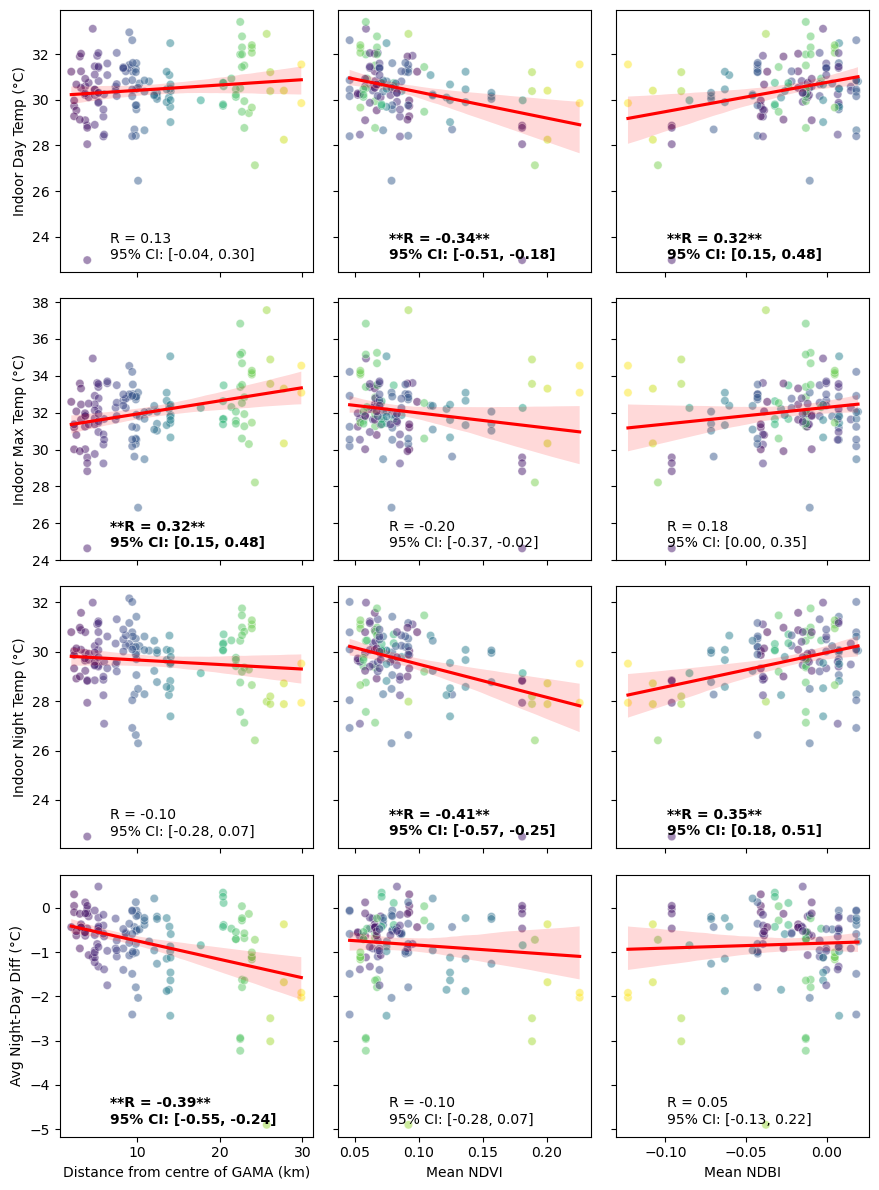

In [12]:
def annotate_fit_r(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(df) < 2:
        return
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    r = np.sqrt(model.rsquared) if model.params['x'] > 0 else -np.sqrt(model.rsquared)
    
    # Calculate the confidence interval for R using Pearson correlation
    r_value, p_value = stats.pearsonr(df['x'], df['y'])
    ci_low, ci_high = stats.norm.interval(0.95, loc=r_value, scale=np.sqrt((1-r_value**2)/(len(df)-2)))
    
    # Bonferroni corrected significance level
    corrected_p = 0.05 / 26
    significant = p_value < corrected_p

    # Annotate with bold and asterisk if significant
    if significant:
        ax.annotate(f'**R = {r_value:.2f}**\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]', 
                    xy=(0.2, 0.05), xycoords='axes fraction', fontsize=10, fontweight='bold')
    else:
        ax.annotate(f'R = {r_value:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]', 
                    xy=(0.2, 0.05), xycoords='axes fraction', fontsize=10)

# Choose the analysis level
analysis_level = 'aggregated'  # Set to either 'day_level' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame = day_level
    axis_prefix = 'daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data

# Create the 4x3 plot grid
fig, axes = plt.subplots(4, 3, figsize=(9, 12), sharex='col', sharey='row')

# Define the variables to plot
x_vars = ['distance', 'mean_ndvi', 'mean_ndbi']
y_vars = [
    'average_daily_mean_indoor',
    'average_daily_max_indoor',
    'average_daily_mean_indoor',
    'average_diff_indoor'
]

day_night_flags = ['Day', 'Day', 'Night', 'None']

titles = ['Distance from centre of GAMA (km)', 'Mean NDVI', 'Mean NDBI']
y_labels = [
    'Indoor Day Temp (°C)',
    'Indoor Max Temp (°C)',
    'Indoor Night Temp (°C)',
    'Avg Night-Day Diff (°C)'
]

# Plot each combination
for i, (y_var, day_night_flag) in enumerate(zip(y_vars, day_night_flags)):
    for j, (x_var, title) in enumerate(zip(x_vars, titles)):
        ax = axes[i, j]
        if day_night_flag != 'None':
            data = analysis_frame[analysis_frame['Day/night'] == day_night_flag]
        else:
            data = aggregated_diff
        sns.scatterplot(
            data=data, 
            x=x_var, 
            y=y_var,
            hue='distance',
            palette='viridis',
            alpha=0.5,
            legend=False,
            ax=ax
        )
        sns.regplot(
            data=data, 
            x=x_var, 
            y=y_var,
            scatter=False,
            line_kws={'color': 'red'},
            ci=95,
            ax=ax
        )
        if j == 0:
            ax.set_ylabel(y_labels[i])
        else:
            ax.set_ylabel('')
        if i == 3:
            ax.set_xlabel(title)
        else:
            ax.set_xlabel('')
        annotate_fit_r(data[x_var], data[y_var], ax)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.1)

# Save and show the plot
plt.savefig(f"paper_plots/distance_ndvi/sensitivity_plots/{ref_label}/{analysis_level}_indoor_temperature_vs_distance_ndvi_ndbi_R_{ref_label}.png", bbox_inches='tight')
plt.show()


In [13]:
# Assuming your dataframe has a datetime column named "timestamp"
merged_df['Date'] = merged_df['Date/Time'].dt.date

# Step 1: Day-Level Aggregation with 'site_type_outdoor'
day_level = merged_df.groupby(['sensor_id_indoor_temp', 'Date', 'Day/night']).agg(
    daily_mean_indoor=('Indoor_Value', 'mean'),
    daily_mean_outdoor=('Value', 'mean'),
    daily_max_indoor=('Indoor_Value', 'max'),
    daily_max_outdoor=('Value', 'max'),
    site_type_outdoor=('site_type_outdoor', 'first'),
    mean_ndvi=('mean_ndvi', 'first'),
    mean_ndbi=('mean_ndbi', 'first'),
    distance=('distance', 'first')
).reset_index()

# Step 2: Calculate daily differences (indoor - outdoor)
day_level['daily_diff_mean'] = day_level['daily_mean_indoor'] - day_level['daily_mean_outdoor']
day_level['daily_diff_max'] = day_level['daily_max_indoor'] - day_level['daily_max_outdoor']

# Ensure columns for NDVI, NDBI, and distance exist for both day and night
day_diff = day_level.pivot(index=['sensor_id_indoor_temp', 'Date'], columns='Day/night', values=['daily_mean_outdoor', 'daily_mean_indoor', 'daily_diff_mean', 'mean_ndvi', 'mean_ndbi', 'distance'])
day_diff.columns = ['_'.join(col).strip() for col in day_diff.columns.values]
day_diff = day_diff.reset_index()

# Step 3: Sensor-Level Aggregation
aggregated_data = day_level.groupby(['sensor_id_indoor_temp', 'Day/night']).agg(
    average_daily_mean_indoor=('daily_mean_indoor', 'mean'),
    average_daily_mean_outdoor=('daily_mean_outdoor', 'mean'),
    average_daily_max_indoor=('daily_max_indoor', 'mean'),
    average_daily_max_outdoor=('daily_max_outdoor', 'mean'),
    average_daily_diff_mean=('daily_diff_mean', 'mean'),
    mean_ndvi=('mean_ndvi', 'first'),
    mean_ndbi=('mean_ndbi', 'first'),
    distance=('distance', 'first')
).reset_index()

# Aggregated day-night differences
aggregated_diff = day_diff.groupby('sensor_id_indoor_temp').agg(
    average_diff_mean=('daily_diff_mean_Night', 'mean'),
    mean_ndvi=('mean_ndvi_Day', 'first'),
    mean_ndbi=('mean_ndbi_Day', 'first'),
    distance=('distance_Day', 'first')
).reset_index()


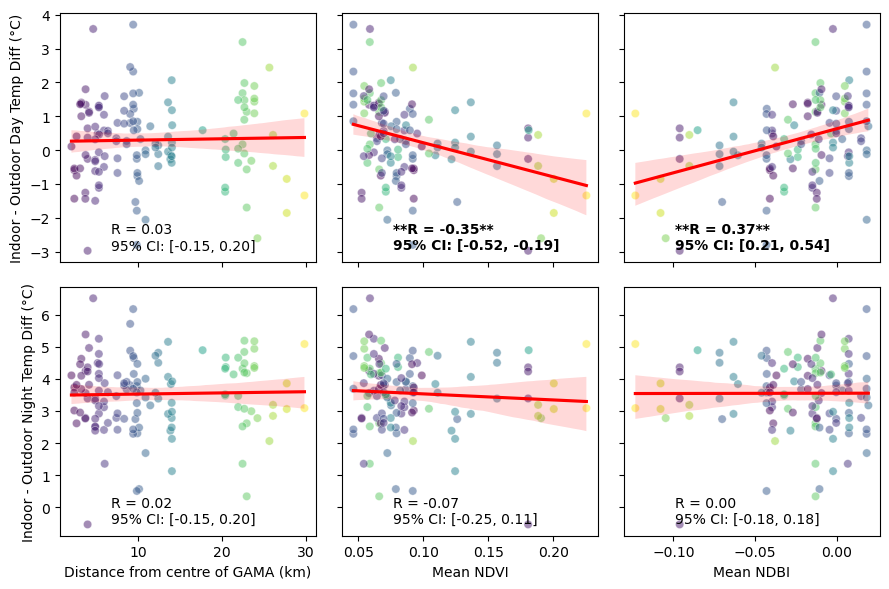

In [14]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

def annotate_fit_r(x, y, ax):
    # Drop NaN values
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(df) < 2:
        return
    X = sm.add_constant(df['x'])
    model = sm.OLS(df['y'], X).fit()
    r = np.sqrt(model.rsquared) if model.params['x'] > 0 else -np.sqrt(model.rsquared)
    
    # Calculate the confidence interval for R using Pearson correlation
    r_value, p_value = stats.pearsonr(df['x'], df['y'])
    ci_low, ci_high = stats.norm.interval(0.95, loc=r_value, scale=np.sqrt((1-r_value**2)/(len(df)-2)))
    
    # Bonferroni corrected significance level
    corrected_p = 0.05 / 26
    significant = p_value < corrected_p

    # Annotate with bold and asterisk if significant
    if significant:
        ax.annotate(f'**R = {r_value:.2f}**\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]', 
                    xy=(0.2, 0.05), xycoords='axes fraction', fontsize=10, fontweight='bold')
    else:
        ax.annotate(f'R = {r_value:.2f}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]', 
                    xy=(0.2, 0.05), xycoords='axes fraction', fontsize=10)

# Choose the analysis level
analysis_level = 'aggregated'  # Set to either 'day_level' or 'aggregated'

if analysis_level == 'day_level':
    analysis_frame = day_level
    axis_prefix = 'daily'
elif analysis_level == 'aggregated':
    analysis_frame = aggregated_data

# Create the 2x3 plot grid
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex='col', sharey='row')

# Define the variables to plot
x_vars = ['distance', 'mean_ndvi', 'mean_ndbi']
y_vars = [
    'average_daily_diff_mean',
    'average_diff_mean'
]

day_night_flags = ['Day', 'None']

titles = ['Distance from centre of GAMA (km)', 'Mean NDVI', 'Mean NDBI']
y_labels = [
    'Indoor - Outdoor Day Temp Diff (°C)',
    'Indoor - Outdoor Night Temp Diff (°C)'
]

# Plot each combination
for i, (y_var, day_night_flag) in enumerate(zip(y_vars, day_night_flags)):
    for j, (x_var, title) in enumerate(zip(x_vars, titles)):
        ax = axes[i, j]
        if day_night_flag != 'None':
            data = analysis_frame[analysis_frame['Day/night'] == day_night_flag]
        else:
            data = aggregated_diff
        sns.scatterplot(
            data=data, 
            x=x_var, 
            y=y_var,
            hue='distance',
            palette='viridis',
            alpha=0.5,
            legend=False,
            ax=ax
        )
        sns.regplot(
            data=data, 
            x=x_var, 
            y=y_var,
            scatter=False,
            line_kws={'color': 'red'},
            ci=95,
            ax=ax
        )
        if j == 0:
            ax.set_ylabel(y_labels[i])
        else:
            ax.set_ylabel('')
        if i == 1:
            ax.set_xlabel(title)
        else:
            ax.set_xlabel('')
        annotate_fit_r(data[x_var], data[y_var], ax)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1, wspace=0.1)

# Save and show the plot
plt.savefig(f"paper_plots/distance_ndvi/sensitivity_plots/{ref_label}/{analysis_level}_indoor_outdoor_diff_vs_distance_ndvi_ndbi_R_{ref_label}.png", bbox_inches='tight')
plt.show()
